## IDMC — Internal Displacement Monitoring Centre

IDMC tracks conflict-induced internal displacements at the country-day level, aggregated here to country-month. `monthly_displacement` captures the number of new internally displaced persons (IDPs) registered each month due to conflict. This variable is central to the project as it directly feeds into the construction of `allocation-eligible`, a country meets the CERF criteria when it accumulates 50,000 or more new displacements over a 3-month period. For this reason.

In [2]:
import os
import pandas as pd
import numpy as np

df = pd.read_csv('../data_clean/final_data.csv')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (17424, 100)


In [3]:
# Descriptive statistics - monthly displacement
print(df['monthly_displacement'].describe().round(2))
print(f"\nMissing values: {df['monthly_displacement'].isnull().sum()}")
print(f"Missing percentage: {(df['monthly_displacement'].isnull().sum() / len(df) * 100).round(2)}%")

count      17424.00
mean        5066.99
std        59313.96
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      4000000.00
Name: monthly_displacement, dtype: float64

Missing values: 0
Missing percentage: 0.0%


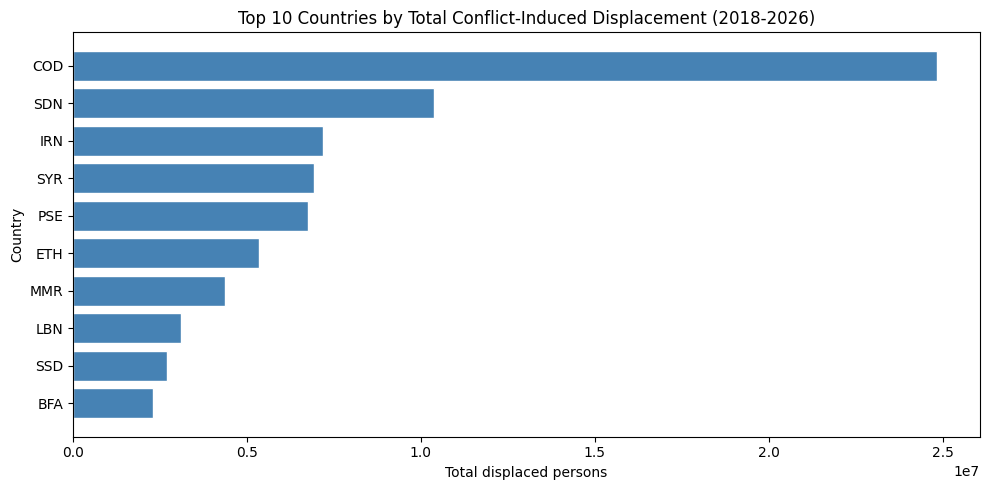

In [7]:
import matplotlib.pyplot as plt

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_disp.index[::-1], top10_disp.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 10 Countries by Total Conflict-Induced Displacement (2018-2026)')
ax.set_xlabel('Total displaced persons')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

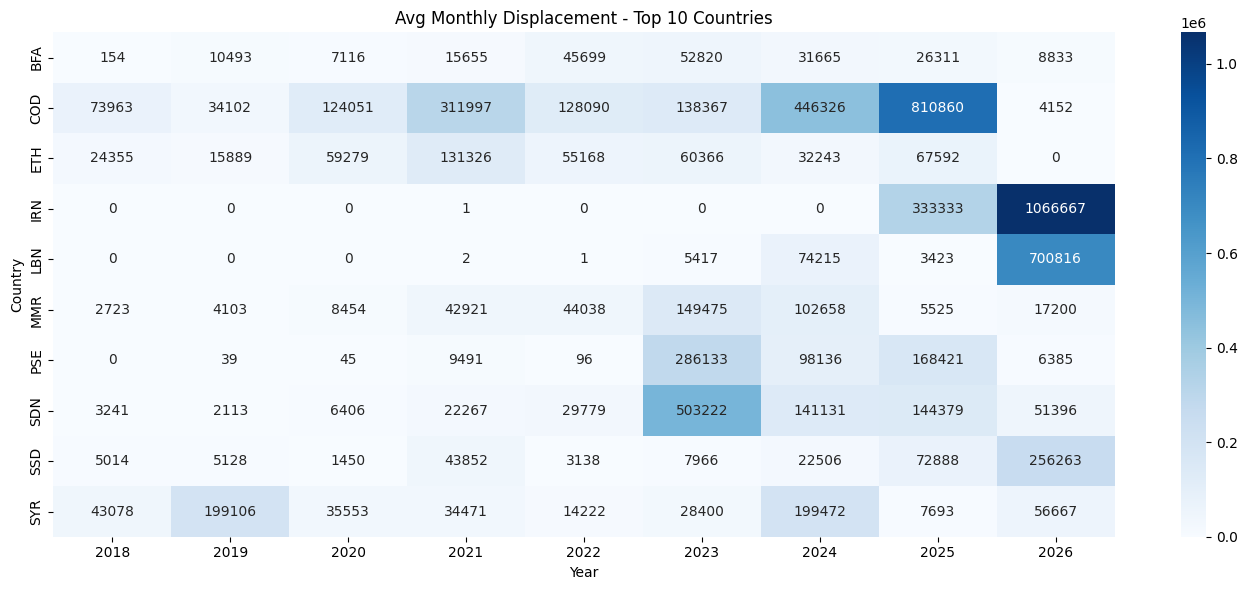

In [10]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10).index

yearly_disp = df[df['iso3'].isin(top10_disp)].groupby(['year', 'iso3'])['monthly_displacement'].mean().round(0)

pivot_disp = yearly_disp.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_disp, cmap='Blues', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Displacement - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap shows the average monthly conflict-induced displacement for the 10 countries with the highest cumulative totals over the study period. COD(Democratic Republic of Congo) stands out as the most affected country throughout the entire period, with displacement levels rising sharply in 2024-2025 to over 800,000 persons per month on average. Several countries show sudden escalations tied to specific conflict events. Sudan (SDN) records a sharp spike in 2023 coinciding with the outbreak of civil war between the SAF and RSF forces. Palestine (PSE) shows near-zero displacement until 2023, when the Gaza conflict begins. Iran (IRN) and Lebanon (LBN) appear relatively stable until 2025-2026, when displacement surges to over 1 million and 700,000 monthly respectively, likely linked to regional escalation in the Middle East. Syria (SYR) shows a different pattern , high displacement in the early years of the study period that gradually declines, reflecting the de-escalation of the Syrian civil war after its peak years.

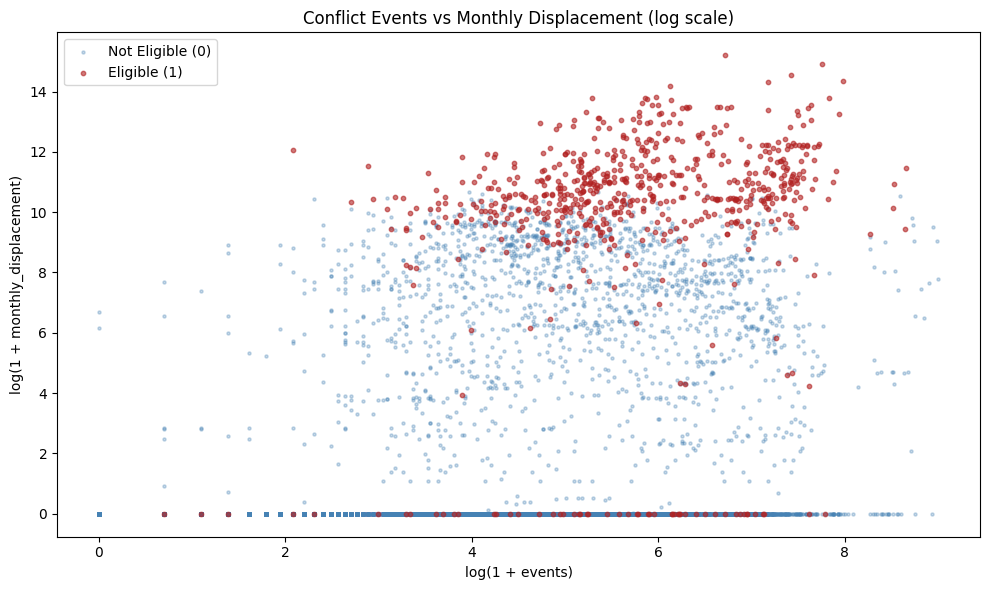

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Non-eligible
mask0 = df['allocation-eligible'] == 0
ax.scatter(np.log1p(df[mask0]['events']), np.log1p(df[mask0]['monthly_displacement']),
           alpha=0.3, color='steelblue', s=5, label='Not Eligible (0)')

# Eligible
mask1 = df['allocation-eligible'] == 1
ax.scatter(np.log1p(df[mask1]['events']), np.log1p(df[mask1]['monthly_displacement']),
           alpha=0.6, color='firebrick', s=10, label='Eligible (1)')

ax.set_title('Conflict Events vs Monthly Displacement (log scale)')
ax.set_xlabel('log(1 + events)')
ax.set_ylabel('log(1 + monthly_displacement)')
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot examines the relationship between conflict activity (ACLED events) and conflict-induced displacement (IDMC) at the country-month level, with both variables on a log scale. Each point represents a country-month observation, colored by allocation-eligible status. Countries that are allocation-eligible (red) cluster in the upper-right region of the chart, indicating that crisis months are characterized by simultaneously high conflict activity and high displacement. In contrast, non-eligible months (blue) are widely dispersed, with a large concentration along y=0, reflecting country-months where conflict events occur but produce no recorded displacement. This pattern suggests that while conflict and displacement are positively associated, not all conflict translates into displacement, the co-occurrence of both at high levels is what characterizes allocation-eligible situations. This reinforces the complementarity of ACLED and IDMC as predictors in the early warning model.